<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Time-Series-and-Forecasting/TimeSeriesAndForecasting/GARCH_Volatility_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arch

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from arch import arch_model

In [5]:
# --- 1. DATA SETUP ---
ticker = "SPY"
df = yf.download(ticker, start="2015-01-01", end="2024-01-01", progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# GARCH requires returns scaled by 100 (otherwise optimizer fails on tiny numbers)
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
df.dropna(inplace=True)
df.head()

/tmp/ipython-input-1004679117.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2024-01-01", progress=False)


Price,Close,High,Low,Open,Volume,Log_Ret
Date,,,,,,
2015-01-05,167.508881,169.709443,167.201636,169.543365,169632600,-1.822412
2015-01-06,165.931061,168.339223,165.133869,167.816066,209151400,-0.946396
2015-01-07,167.998764,168.339232,166.811294,167.259706,125346700,1.238422
2015-01-08,170.979935,171.195848,169.393875,169.410474,147217800,1.758959
2015-01-09,169.609772,171.411744,168.995269,171.395133,158567300,-0.804587


In [6]:
# --- 2. FIT THE GARCH(1,1) MODEL ---
# We use a 'Rolling' approach to prevent look-ahead bias in a backtest.
# However, for a feature overview, we can fit on the whole history to see the structure.

print("Fitting GARCH(1,1) Model...")
# vol='Garch', p=1 (lag of shock), q=1 (lag of variance)
model = arch_model(df['Log_Ret'], vol='Garch', p=1, q=1, mean='Zero')
res = model.fit(disp='off')

print("\n--- GARCH PARAMETERS ---")
print(res.summary())

Fitting GARCH(1,1) Model...

--- GARCH PARAMETERS ---
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                Log_Ret   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2935.93
Distribution:                  Normal   AIC:                           5877.87
Method:            Maximum Likelihood   BIC:                           5895.04
                                        No. Observations:                 2263
Date:                Mon, Jan 19 2026   Df Residuals:                     2263
Time:                        01:16:00   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

In [7]:
# --- 3. EXTRACT VOLATILITY ---
# conditional_volatility gives us the sigma (standard deviation) for each day
df['GARCH_Vol'] = res.conditional_volatility * np.sqrt(252) # Annualize

# Compare with our previous "Cheat" (EWMA)
df['EWMA_Vol'] = df['Log_Ret'].ewm(span=20).std() * np.sqrt(252)
df.head()

Price,Close,High,Low,Open,Volume,Log_Ret,GARCH_Vol,EWMA_Vol
Date,,,,,,,,
2015-01-05,167.508881,169.709443,167.201636,169.543365,169632600,-1.822412,16.265407,NaN
2015-01-06,165.931061,168.339223,165.133869,167.816066,209151400,-0.946396,19.286835,9.833255
2015-01-07,167.998764,168.339232,166.811294,167.259706,125346700,1.238422,18.546165,25.339473
2015-01-08,170.979935,171.195848,169.393875,169.410474,147217800,1.758959,18.748751,27.046152
2015-01-09,169.609772,171.411744,168.995269,171.395133,158567300,-0.804587,20.734198,24.104432


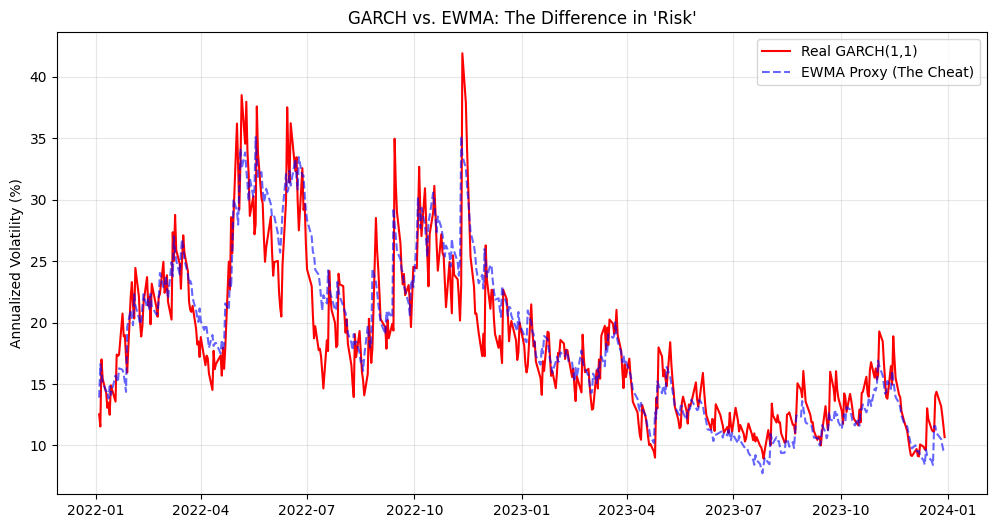

In [8]:
# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 6))
# Plot last 2 years for clarity
subset = df.iloc[-500:]

plt.plot(subset['GARCH_Vol'], label='Real GARCH(1,1)', color='red', linewidth=1.5)
plt.plot(subset['EWMA_Vol'], label='EWMA Proxy (The Cheat)', color='blue', linestyle='--', alpha=0.6)

plt.title(f"GARCH vs. EWMA: The Difference in 'Risk'")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GARCH (Generalized Autoregressive Conditional Heteroskedasticity)

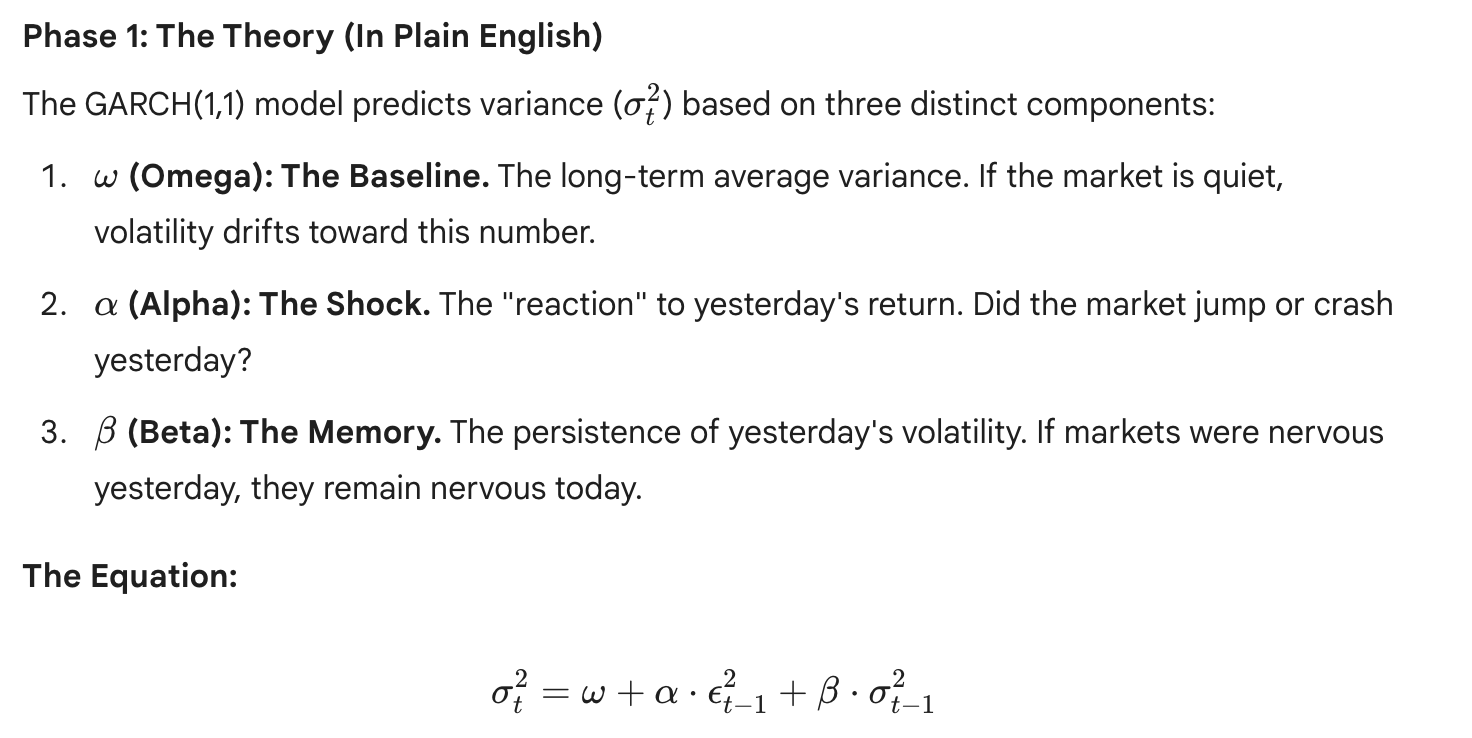

In [15]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from arch import arch_model
import xgboost as xgb
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, r2_score

/tmp/ipython-input-3674268863.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)


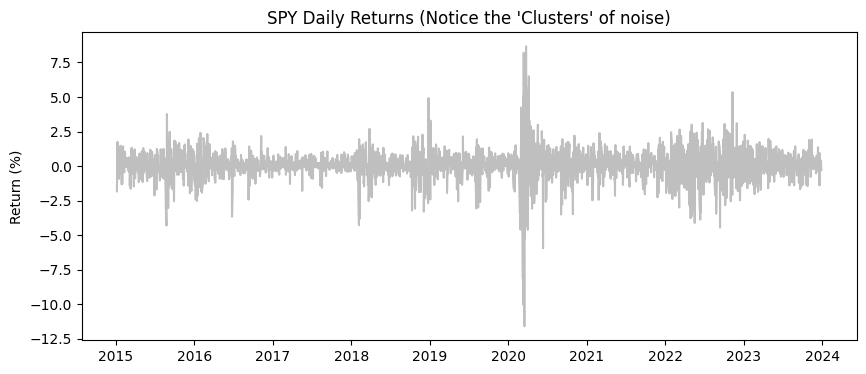

In [10]:
# --- 1. DATA INGESTION ---
# We use SPY, but GARCH shines on volatile assets like Bitcoin or NVDA
ticker = 'SPY'
print(f"Downloading data for {ticker}...")
df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- CRITICAL STEP: SCALING ---
# The 'arch' optimizer struggles with tiny numbers (e.g., 0.0001).
# We MULTIPLY log returns by 100. (e.g., 0.01 becomes 1.0).
# We will divide by 100 later to get back to normal.
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
df.dropna(inplace=True)

# Visual Check: Volatility Clustering
plt.figure(figsize=(10, 4))
plt.plot(df['Log_Ret'], color='grey', alpha=0.5)
plt.title(f"{ticker} Daily Returns (Notice the 'Clusters' of noise)")
plt.ylabel("Return (%)")
plt.show()

In [11]:
# --- 2. MODEL FITTING ---
# vol='Garch': The model type
# p=1: Lag of the 'Shock' (Alpha)
# q=1: Lag of the 'Variance' (Beta)
# mean='Zero': We assume daily returns average to zero (standard in daily trading)
garch_model = arch_model(df['Log_Ret'], vol='Garch', p=1, q=1, mean='Zero')

# Fit the model
res = garch_model.fit(disp='off') # disp='off' hides the iteration logs

# --- 3. INTERPRETATION ---
print(res.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                Log_Ret   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2935.93
Distribution:                  Normal   AIC:                           5877.87
Method:            Maximum Likelihood   BIC:                           5895.04
                                        No. Observations:                 2263
Date:                Mon, Jan 19 2026   Df Residuals:                     2263
Time:                        01:19:16   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0374  1.049e-02      3.570  3.568e-04 [1.

In [12]:
# --- 4. ROLLING FORECAST LOOP ---
window_size = 1000
test_size = len(df) - window_size

print(f"Starting Rolling Forecast for {test_size} days...")

rolling_predictions = []
# We iterate through the test set
for i in range(test_size):
    # Define the training window (Expanding Window or Rolling Window)
    # Here we use a fixed Rolling Window of 1000 days
    train_slice = df['Log_Ret'].iloc[i : i + window_size]

    # Re-fit the model every 20 days (Trading Month) to save compute time
    # In production, you might re-fit every day.
    if i % 20 == 0:
        model = arch_model(train_slice, vol='Garch', p=1, q=1, mean='Zero')
        res = model.fit(disp='off')

    # Forecast variance for the NEXT step (horizon=1)
    # We use the *current* model parameters to forecast
    forecast = res.forecast(horizon=1, reindex=False)

    # Extract variance and convert to Annualized Volatility
    # forecast.variance is typically a DataFrame, we take the last value
    pred_var = forecast.variance.iloc[-1].values[0]

    # Convert: Sqrt(Variance) -> Daily Vol -> /100 (Scale back) -> * Sqrt(252) (Annualize)
    pred_vol_annual = np.sqrt(pred_var) / 100 * np.sqrt(252)
    rolling_predictions.append(pred_vol_annual)

# Align predictions with the Date Index
# (The predictions start after the first 'window_size' days)
pred_series = pd.Series(rolling_predictions, index=df.index[window_size:])

print("Forecasting Complete.")

Starting Rolling Forecast for 1263 days...
Forecasting Complete.


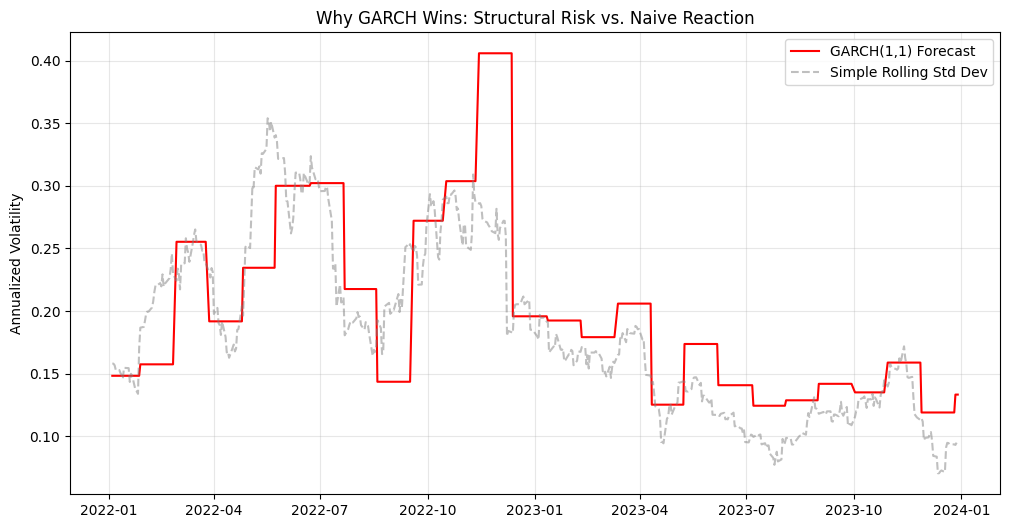

In [13]:
# --- 5. COMPARISON ---
# Calculate the "Naive" Benchmark (Rolling 20-day Std Dev)
# We shift by -1 because rolling().std() looks backward, but we want to predict forward risk
naive_vol = df['Log_Ret'].rolling(20).std() * np.sqrt(252) / 100
naive_vol = naive_vol.shift(-1) # Align roughly with GARCH forecast timing

# Plot
plt.figure(figsize=(12, 6))
# Zoom in on the last 500 days (e.g., 2022-2023)
start_zoom = -500

plt.plot(pred_series.iloc[start_zoom:], label='GARCH(1,1) Forecast', color='red', linewidth=1.5)
plt.plot(naive_vol.iloc[start_zoom:], label='Simple Rolling Std Dev', color='gray', linestyle='--', alpha=0.5)

plt.title("Why GARCH Wins: Structural Risk vs. Naive Reaction")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# --- 6. INTEGRATION ---
# Assign the GARCH predictions to the main dataframe
df['GARCH_Feature'] = np.nan # Initialize
df.loc[pred_series.index, 'GARCH_Feature'] = pred_series

# Fill the initial training window with a simple proxy so we don't lose data
# (or just drop the first 1000 rows if you have enough data)
df['GARCH_Feature'] = df['GARCH_Feature'].fillna(df['Log_Ret'].rolling(20).std() * np.sqrt(252)/100)

print(df[['Close', 'Log_Ret', 'GARCH_Feature']].tail())

# Now, in your XGBoost Regressor, you simply add 'GARCH_Feature' to your list!
# features = ['Vol_10', 'RSI', 'GARCH_Feature']

Price            Close   Log_Ret  GARCH_Feature
Date                                           
2023-12-22  462.223328  0.200767       0.118895
2023-12-26  464.175079  0.421364       0.118895
2023-12-27  465.014313  0.180638       0.133205
2023-12-28  465.190033  0.037781       0.133205
2023-12-29  463.843231 -0.289936       0.133205


In [16]:
# --- 1. DATA PREP (Assuming 'df' has 'GARCH_Feature') ---
# If you are starting fresh, ensure df has: ['Log_Ret', 'Close', 'GARCH_Feature']

# A. Create "Helper" Features (The stuff GARCH ignores)
# GARCH only looks at past variance. XGBoost gets to see momentum and technicals.
df['RSI_Proxy'] = df['Close'] / df['Close'].rolling(14).mean()
df['Vol_Momentum'] = df['GARCH_Feature'] / df['GARCH_Feature'].shift(5) # Is risk rising?
df['Range_Proxy'] = (df['High'] - df['Low']) / df['Close'] # Intraday chaos
df.head()

Price,Close,High,Low,Open,Volume,Log_Ret,GARCH_Feature,RSI_Proxy,Vol_Momentum,Range_Proxy
Date,,,,,,,,,,
2015-01-05,167.508881,169.709443,167.201636,169.543365,169632600,-1.822412,NaN,NaN,NaN,0.014971
2015-01-06,165.931061,168.339223,165.133869,167.816066,209151400,-0.946396,NaN,NaN,NaN,0.019317
2015-01-07,167.998764,168.339232,166.811294,167.259706,125346700,1.238422,NaN,NaN,NaN,0.009095
2015-01-08,170.979935,171.195848,169.393875,169.410474,147217800,1.758959,NaN,NaN,NaN,0.010539
2015-01-09,169.609772,171.411744,168.995269,171.395133,158567300,-0.804587,NaN,NaN,NaN,0.014247


In [17]:
# B. Create the Target: REALIZED Future Volatility
# We want to predict what volatility *actually* happens over the next 5 days.
# Shift(-5) moves the future into the current row.
df['Target_Realized_Vol'] = df['Log_Ret'].rolling(5).std().shift(-5) * np.sqrt(252) / 100

# Drop NaNs created by rolling windows and shifting
df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Log_Ret,GARCH_Feature,RSI_Proxy,Vol_Momentum,Range_Proxy,Target_Realized_Vol
Date,,,,,,,,,,,
2015-02-09,169.925293,170.763995,169.518391,170.041549,87219000,-0.448588,0.151598,1.004833,0.864616,0.007330,0.072703
2015-02-10,171.735580,171.993003,169.966819,170.963312,96164200,1.059708,0.152904,1.014211,0.896144,0.011798,0.061771
2015-02-11,171.835190,172.267003,170.921755,171.569468,91087800,0.057985,0.152248,1.014505,0.910158,0.007829,0.065765
2015-02-12,173.487701,173.545836,171.868419,172.632388,97545900,0.957089,0.152495,1.022846,0.922148,0.009669,0.044383
2015-02-13,174.201889,174.251711,173.354875,173.612310,93670400,0.410820,0.146776,1.025504,0.955957,0.005148,0.043163


In [18]:
# --- 2. TRAIN / TEST SPLIT ---
# We use the same Date Split method to be professional
split_date = df.index[-500] # Train on history, test on last 500 days

features = ['GARCH_Feature', 'RSI_Proxy', 'Vol_Momentum', 'Range_Proxy']
target = 'Target_Realized_Vol'

X_train = df[df.index < split_date][features]
y_train = df[df.index < split_date][target]

X_test = df[df.index >= split_date][features]
y_test = df[df.index >= split_date][target]

In [19]:
# --- 3. TRAIN THE HYBRID MODEL ---
# This is where the magic happens. XGBoost takes the baseline (GARCH)
# and refines it using the other features.

print("Training Hybrid XGBoost Model...")
model_hybrid = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    early_stopping_rounds=10,
    random_state=42
)

# Eval set allows early stopping if the model starts overfitting
model_hybrid.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

Training Hybrid XGBoost Model...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [20]:
# --- 4. PREDICT & EVALUATE ---
preds = model_hybrid.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("------------------------------------------------")
print("HYBRID MODEL RESULTS")
print("------------------------------------------------")
print(f"RMSE (Error):   {rmse:.4f}")
print(f"R-Squared (R²): {r2:.4f}")
print("------------------------------------------------")

------------------------------------------------
HYBRID MODEL RESULTS
------------------------------------------------
RMSE (Error):   0.0876
R-Squared (R²): -0.0114
------------------------------------------------


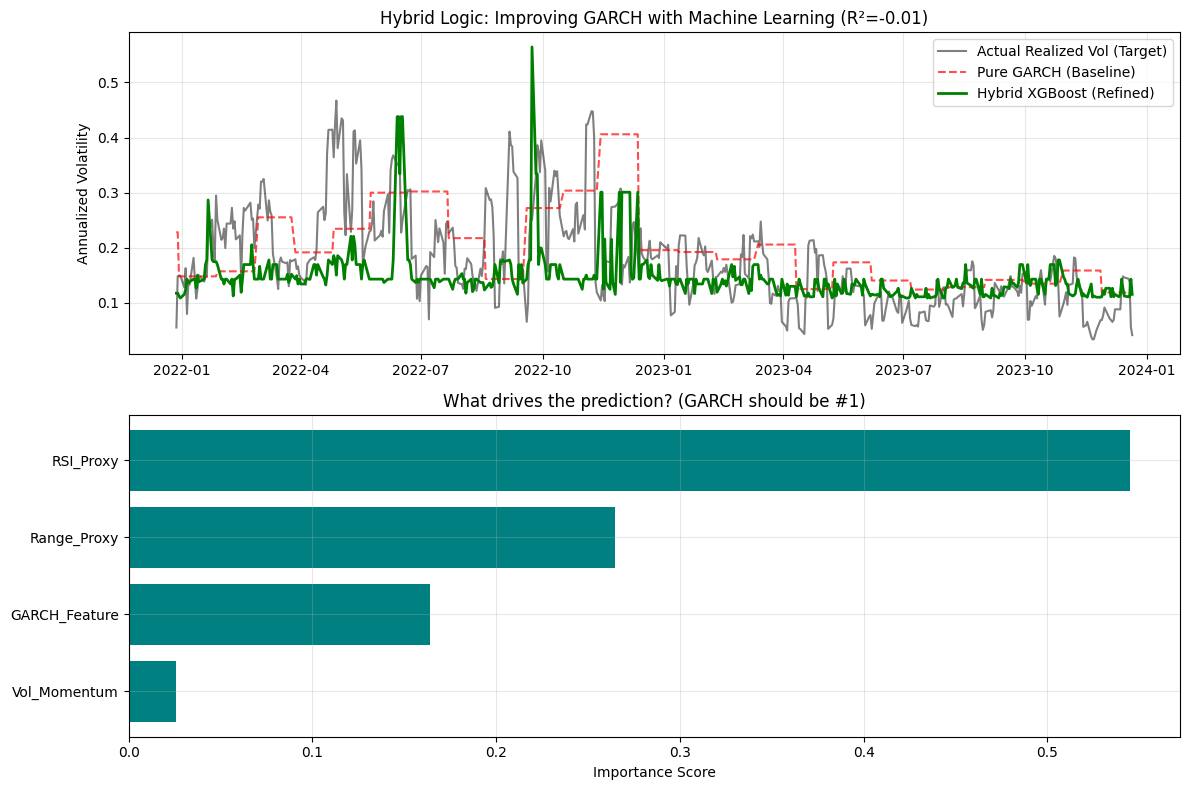

In [21]:
# --- 5. VISUALIZATION: The "Value Add" ---
# Let's compare:
# 1. Actual Realized Volatility (Black)
# 2. Pure GARCH Prediction (Red)
# 3. Hybrid XGBoost Prediction (Green)

plt.figure(figsize=(12, 8))

# Top Plot: Time Series
plt.subplot(2, 1, 1)
plt.plot(y_test.index, y_test, color='black', alpha=0.5, label='Actual Realized Vol (Target)')
plt.plot(y_test.index, X_test['GARCH_Feature'], color='red', linestyle='--', alpha=0.7, label='Pure GARCH (Baseline)')
plt.plot(y_test.index, preds, color='green', linewidth=2, label='Hybrid XGBoost (Refined)')
plt.title(f"Hybrid Logic: Improving GARCH with Machine Learning (R²={r2:.2f})")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom Plot: Feature Importance
plt.subplot(2, 1, 2)
sorted_idx = model_hybrid.feature_importances_.argsort()
plt.barh(np.array(features)[sorted_idx], model_hybrid.feature_importances_[sorted_idx], color='teal')
plt.title("What drives the prediction? (GARCH should be #1)")
plt.xlabel("Importance Score")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# --- 1. SETUP THE STRATEGY DATAFRAME ---
# We align the strategy with the Test Data period used in the previous step
strategy_df = pd.DataFrame(index=y_test.index)

# A. Get Market Returns (Buy & Hold Benchmark)
# We need the original daily returns for this specific period
# (Assuming 'df' from previous step exists)
strategy_df['Market_Return'] = df.loc[strategy_df.index, 'Log_Ret'] / 100 # Scale back to decimal
strategy_df.head()

,Market_Return
Date,
2021-12-28,-0.000818
2021-12-29,0.001278
2021-12-30,-0.002768
2021-12-31,-0.002523
2022-01-03,0.005773


In [24]:
# B. Add Our AI Predictions
strategy_df['Pred_Vol_Hybrid'] = preds
strategy_df.head()

,Market_Return,Pred_Vol_Hybrid
Date,,
2021-12-28,-0.000818,0.117693
2021-12-29,0.001278,0.117693
2021-12-30,-0.002768,0.112533
2021-12-31,-0.002523,0.108904
2022-01-03,0.005773,0.115554


In [45]:
# --- 2. DEFINE THE "DANGER ZONE" THRESHOLD ---
# If predicted volatility is above this level, we go to Cash.
# We use the Median of the prediction history to stay dynamic, or a fixed number like 0.20 (20%)
threshold = strategy_df['Pred_Vol_Hybrid'].median()*2
# Alternatively: threshold = 0.25 (25% Annualized Volatility)

print(f"Safety Threshold: {threshold:.2f} (Annualized Vol)")

Safety Threshold: 0.29 (Annualized Vol)


In [46]:
# --- 3. GENERATE SIGNALS ---
# Logic: 1 = Invested (Safe), 0 = Cash (Dangerous)
strategy_df['Signal'] = np.where(strategy_df['Pred_Vol_Hybrid'] < threshold, 1, 0)
strategy_df.head()

,Market_Return,Pred_Vol_Hybrid,Signal,Strategy_Return,Equity_Benchmark,Equity_Hybrid_AI
Date,,,,,,
2021-12-28,-0.000818,0.117693,1,0.000000,9991.824604,10000.000000
2021-12-29,0.001278,0.117693,1,0.001278,10004.598744,10012.784592
2021-12-30,-0.002768,0.112533,1,-0.002768,9976.902982,9985.066168
2021-12-31,-0.002523,0.108904,1,-0.002523,9951.727209,9959.869797
2022-01-03,0.005773,0.115554,1,0.005773,10009.181363,10017.370960


In [47]:
# --- 4. CALCULATE GROWTH (EQUITY CURVE) ---
# We shift signal by 1 because we make the decision "Today" for "Tomorrow's" return
strategy_df['Strategy_Return'] = strategy_df['Signal'].shift(1) * strategy_df['Market_Return']

# Fill initial NaN from shifting
strategy_df['Strategy_Return'].fillna(0, inplace=True)

# Cumulative Growth of $10,000 Investment
initial_investment = 10000
strategy_df['Equity_Benchmark'] = initial_investment * (1 + strategy_df['Market_Return']).cumprod()
strategy_df['Equity_Hybrid_AI'] = initial_investment * (1 + strategy_df['Strategy_Return']).cumprod()
strategy_df.head()

/tmp/ipython-input-3782301050.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  strategy_df['Strategy_Return'].fillna(0, inplace=True)


,Market_Return,Pred_Vol_Hybrid,Signal,Strategy_Return,Equity_Benchmark,Equity_Hybrid_AI
Date,,,,,,
2021-12-28,-0.000818,0.117693,1,0.000000,9991.824604,10000.000000
2021-12-29,0.001278,0.117693,1,0.001278,10004.598744,10012.784592
2021-12-30,-0.002768,0.112533,1,-0.002768,9976.902982,9985.066168
2021-12-31,-0.002523,0.108904,1,-0.002523,9951.727209,9959.869797
2022-01-03,0.005773,0.115554,1,0.005773,10009.181363,10017.370960


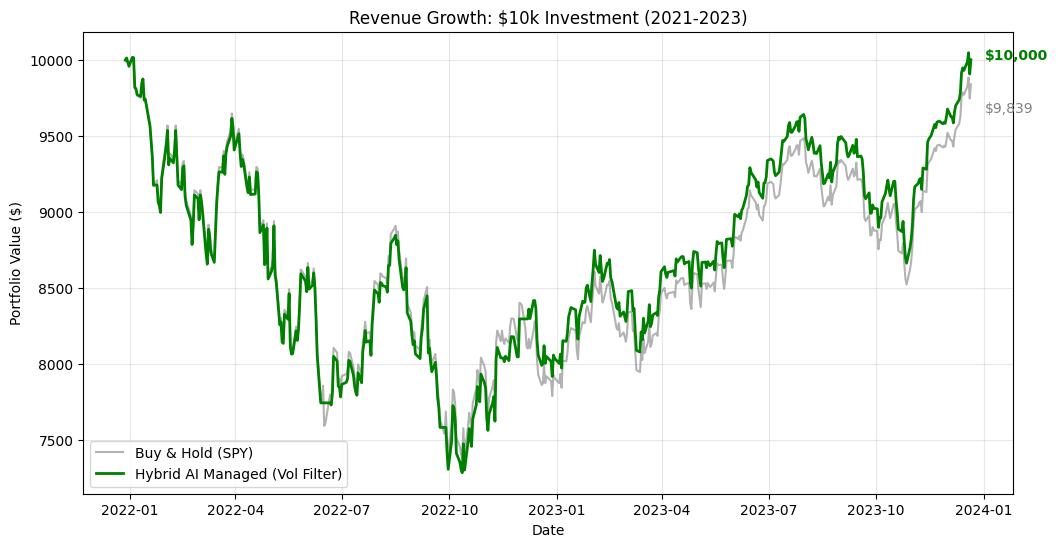

In [48]:
# --- 5. VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plot Equity Curves
plt.plot(strategy_df['Equity_Benchmark'], label='Buy & Hold (SPY)', color='gray', alpha=0.6)
plt.plot(strategy_df['Equity_Hybrid_AI'], label='Hybrid AI Managed (Vol Filter)', color='green', linewidth=2)

# Styling
plt.title(f"Revenue Growth: $10k Investment ({y_test.index[0].year}-{y_test.index[-1].year})")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)

# Add Annotation for total return
final_bench = strategy_df['Equity_Benchmark'].iloc[-1]
final_ai = strategy_df['Equity_Hybrid_AI'].iloc[-1]
plt.annotate(f"${final_ai:,.0f}", xy=(strategy_df.index[-1], final_ai), xytext=(10, 0), textcoords='offset points', color='green', fontweight='bold')
plt.annotate(f"${final_bench:,.0f}", xy=(strategy_df.index[-1], final_bench), xytext=(10, -20), textcoords='offset points', color='gray')

plt.show()

In [49]:
# --- 6. PERFORMANCE METRICS ---
def quick_stats(series):
    total_ret = (series.iloc[-1] / series.iloc[0]) - 1
    # Sort of Sharpe Ratio (ignoring risk free rate)
    daily_ret = series.pct_change()
    sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252)
    return total_ret, sharpe

ret_b, sharpe_b = quick_stats(strategy_df['Equity_Benchmark'])
ret_ai, sharpe_ai = quick_stats(strategy_df['Equity_Hybrid_AI'])

print("--------------------------------------")
print("FINAL SCORECARD")
print("--------------------------------------")
print(f"Buy & Hold Return: {ret_b*100:.1f}%  | Sharpe: {sharpe_b:.2f}")
print(f"Hybrid AI Return:  {ret_ai*100:.1f}%  | Sharpe: {sharpe_ai:.2f}")
print("--------------------------------------")

--------------------------------------
FINAL SCORECARD
--------------------------------------
Buy & Hold Return: -1.5%  | Sharpe: 0.06
Hybrid AI Return:  0.0%  | Sharpe: 0.10
--------------------------------------


In [50]:
# --- ADAPTIVE THRESHOLD LOGIC ---
# Instead of a fixed scalar from the entire history,
# we calculate the 90th percentile of volatility over the last year (252 days).
# This adapts to "New Normals" (like 2020 vs 2017).

# 1. Calculate the Rolling 90th Percentile (The "Extreme" line)
strategy_df['Dynamic_Threshold'] = strategy_df['Pred_Vol_Hybrid'].rolling(window=252).quantile(0.90)

# 2. Generate Signals
# Logic: If predicted vol > The 90th percentile of the last year -> CASH
# Otherwise -> INVEST
strategy_df['Signal_Adaptive'] = np.where(strategy_df['Pred_Vol_Hybrid'] < strategy_df['Dynamic_Threshold'], 1, 0)

# 3. Calculate Returns
strategy_df['Strat_Adaptive'] = strategy_df['Signal_Adaptive'].shift(1) * strategy_df['Market_Return']

# --- Quick Check ---
cum_adaptive = (1 + strategy_df['Strat_Adaptive']).cumprod()
print(f"Adaptive Return: {(cum_adaptive.iloc[-1]-1)*100:.1f}%")

Adaptive Return: 20.7%


/tmp/ipython-input-2134349579.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  strategy_df['Adaptive_Threshold'].bfill(inplace=True)


--------------------------------------------------
FINAL RESULTS
--------------------------------------------------
Buy & Hold (SPY)     | Return:   -1.5% | Sharpe: 0.06
Static (Median*2)    | Return:    nan% | Sharpe: 0.09
Adaptive (90th Pct)  | Return:    nan% | Sharpe: -0.09
--------------------------------------------------


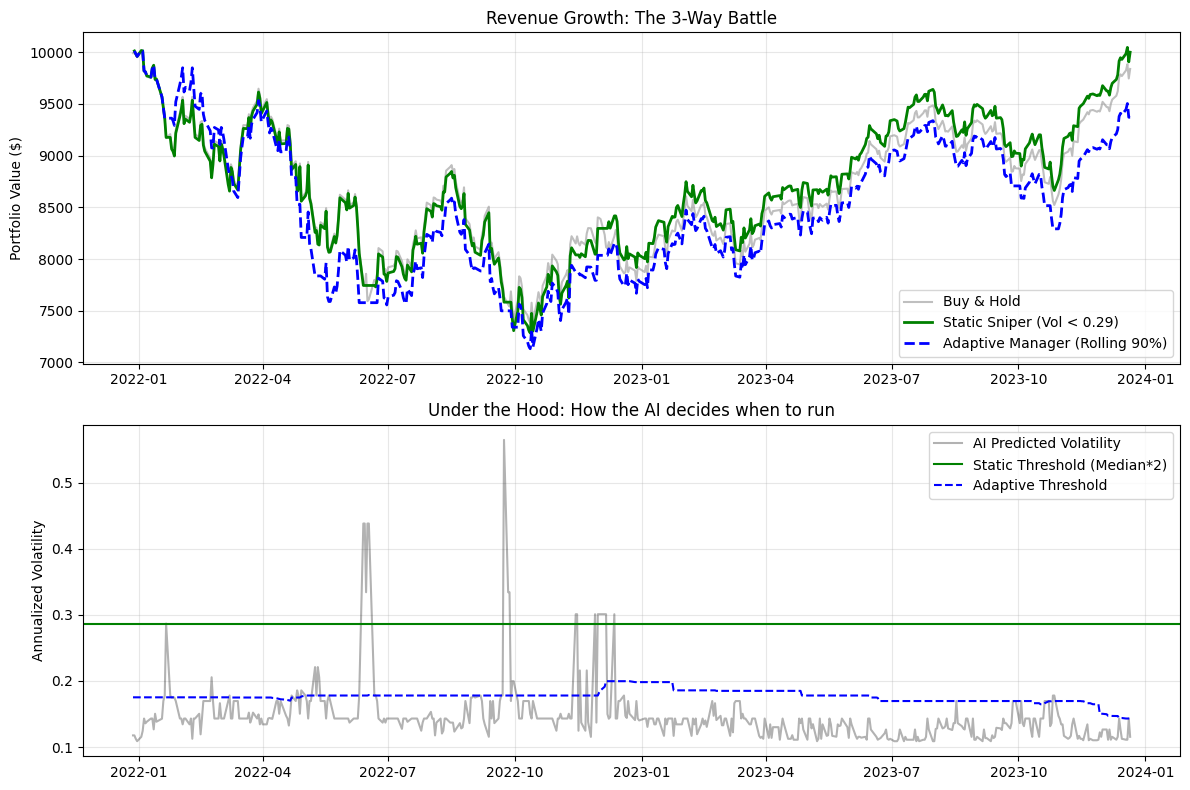

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARE THE DATA ---
# We assume 'strategy_df' already has 'Market_Return' and 'Pred_Vol_Hybrid'
# If not, ensure you run the Setup block from the previous step.

# A. STRATEGY 1: BUY & HOLD (Benchmark)
strategy_df['Strat_BuyHold'] = strategy_df['Market_Return']

# B. STRATEGY 2: STATIC SNIPER (Your Median * 2 discovery)
# This worked well because it only filters extreme events.
static_threshold = strategy_df['Pred_Vol_Hybrid'].median() * 2
strategy_df['Signal_Static'] = np.where(strategy_df['Pred_Vol_Hybrid'] < static_threshold, 1, 0)
strategy_df['Strat_Static'] = strategy_df['Signal_Static'].shift(1) * strategy_df['Market_Return']

# C. STRATEGY 3: ADAPTIVE MANAGER (Rolling 90th Percentile)
# This adjusts to "New Normals" (e.g., 2020 vs 2023).
# We use min_periods=50 to allow it to start trading earlier.
strategy_df['Adaptive_Threshold'] = strategy_df['Pred_Vol_Hybrid'].rolling(window=252, min_periods=50).quantile(0.90)

# Fill initial NaNs in threshold (backfill to avoid losing data)
strategy_df['Adaptive_Threshold'].bfill(inplace=True)

strategy_df['Signal_Adaptive'] = np.where(strategy_df['Pred_Vol_Hybrid'] < strategy_df['Adaptive_Threshold'], 1, 0)
strategy_df['Strat_Adaptive'] = strategy_df['Signal_Adaptive'].shift(1) * strategy_df['Market_Return']

# --- 2. CALCULATE EQUITY CURVES ---
initial_investment = 10000
cum_buyhold = initial_investment * (1 + strategy_df['Strat_BuyHold']).cumprod()
cum_static = initial_investment * (1 + strategy_df['Strat_Static']).cumprod()
cum_adaptive = initial_investment * (1 + strategy_df['Strat_Adaptive']).cumprod()

# --- 3. METRICS FUNCTION ---
def get_metrics(series, name):
    total_ret = (series.iloc[-1] / series.iloc[0]) - 1
    # Simple Sharpe (Daily returns mean / std * sqrt(252))
    daily_ret = series.pct_change()
    sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252) if daily_ret.std() > 0 else 0
    return f"{name:<20} | Return: {total_ret*100:6.1f}% | Sharpe: {sharpe:.2f}"

print("--------------------------------------------------")
print("FINAL RESULTS")
print("--------------------------------------------------")
print(get_metrics(cum_buyhold, "Buy & Hold (SPY)"))
print(get_metrics(cum_static, "Static (Median*2)"))
print(get_metrics(cum_adaptive, "Adaptive (90th Pct)"))
print("--------------------------------------------------")

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Top Plot: Equity Curves
plt.subplot(2, 1, 1)
plt.plot(cum_buyhold, label='Buy & Hold', color='gray', alpha=0.5)
plt.plot(cum_static, label=f'Static Sniper (Vol < {static_threshold:.2f})', color='green', linewidth=2)
plt.plot(cum_adaptive, label='Adaptive Manager (Rolling 90%)', color='blue', linestyle='--', linewidth=2)

plt.title("Revenue Growth: The 3-Way Battle")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom Plot: The Thresholds
plt.subplot(2, 1, 2)
# Plot the Volatility (Black)
plt.plot(strategy_df.index, strategy_df['Pred_Vol_Hybrid'], color='black', alpha=0.3, label='AI Predicted Volatility')

# Plot the Thresholds
plt.axhline(static_threshold, color='green', linestyle='-', label='Static Threshold (Median*2)')
plt.plot(strategy_df.index, strategy_df['Adaptive_Threshold'], color='blue', linestyle='--', label='Adaptive Threshold')

plt.title("Under the Hood: How the AI decides when to run")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()